In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
from google.colab import files
uploaded=files.upload()
df=pd.read_csv("fmnist_small.csv")

Saving fmnist_small.csv to fmnist_small.csv


In [ ]:
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,0,0,0,0,0,0,0,0,0,...,69,12,0,0,0,0,0,0,0,0
5996,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5997,8,0,0,0,0,0,0,0,0,0,...,39,47,2,0,0,29,0,0,0,0
5998,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


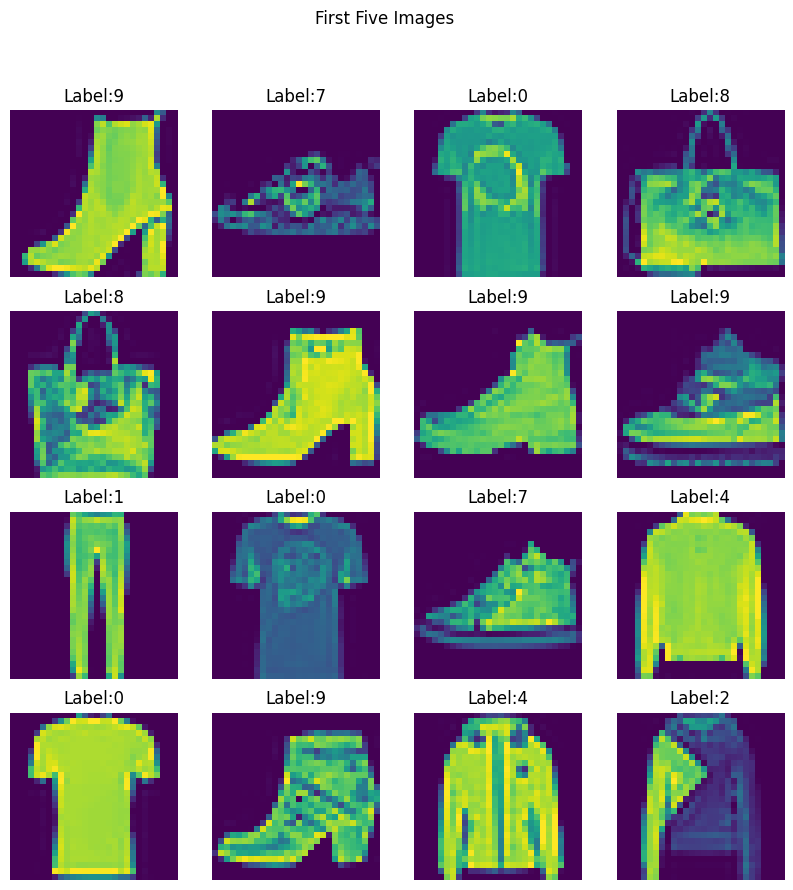

In [ ]:
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First Five Images")

for i,ax in enumerate(axes.flat):
  img=df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label:{df.iloc[i,0]}")

In [ ]:
X=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [ ]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2, random_state=42)

In [ ]:
X_train=X_train/255.0
X_test=X_test/255.0

# CUSTOM DATASET

In [ ]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features=torch.tensor(features,dtype=torch.float32)
    self.labels=torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)
  def __getitem__(self,idx):
    return self.features[idx],self.labels[idx]

In [ ]:
train_dataset=CustomDataset(X_train,y_train)
test_dataset=CustomDataset(X_test,y_test)

In [ ]:
train_dataloader=DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
test_dataloader=DataLoader(test_dataset,batch_size=32,shuffle=False,pin_memory=True)

# Define NN

In [ ]:
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.model=nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )
  def forward(self,features):
    return self.model(features)

In [ ]:
epochs=20
lr=0.1
model=MyNN(X_train.shape[1])
criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=lr)

# Training Loop

In [ ]:
model.to(device)
for epoch in range(epochs):
  total_epoch_loss=0

  for batch_features,batch_labels in train_dataloader:
    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
    output=model(batch_features)
    loss=criterion(output,batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss+=loss.item()
avg_loss=total_epoch_loss/len(train_dataloader)
print(avg_loss)

0.2801090351243814


In [ ]:
model.eval()
total=0
correct=0
with torch.no_grad():
  for batch_features,batch_labels in test_dataloader:
    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
    output=model(batch_features)
    _,predicted=torch.max(output,dim=1)
    total+=batch_labels.size(0)
    correct+=(predicted==batch_labels).sum().item()
accuracy=100*correct/total
print(f"Accuracy:{accuracy}")

Accuracy:83.08333333333333
